Dataset Shape: (50000, 2)
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


C:\Users\23adsb48\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - accuracy: 0.6227 - loss: 0.6284 - val_accuracy: 0.7869 - val_loss: 0.4616
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.8332 - loss: 0.3835 - val_accuracy: 0.8225 - val_loss: 0.4067
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - accuracy: 0.9112 - loss: 0.2262 - val_accuracy: 0.8207 - val_loss: 0.4201
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 27ms/step - accuracy: 0.9574 - loss: 0.1250 - val_accuracy: 0.7986 - val_loss: 0.5396
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - accuracy: 0.9834 - loss: 0.0558 - val_accuracy: 0.8189 - val_loss: 0.6022
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.9918 - loss: 0.0303 - val_accuracy: 0.8051 - val_loss: 0.7140
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.9913 - loss: 0.0282 - val_accuracy: 0.7409 - val_loss: 0.9434
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 25ms/step - accuracy: 0.9935 - loss: 0.0201 - 

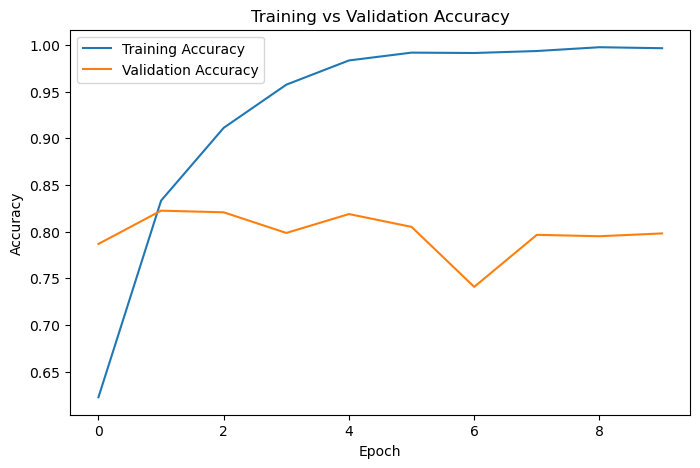

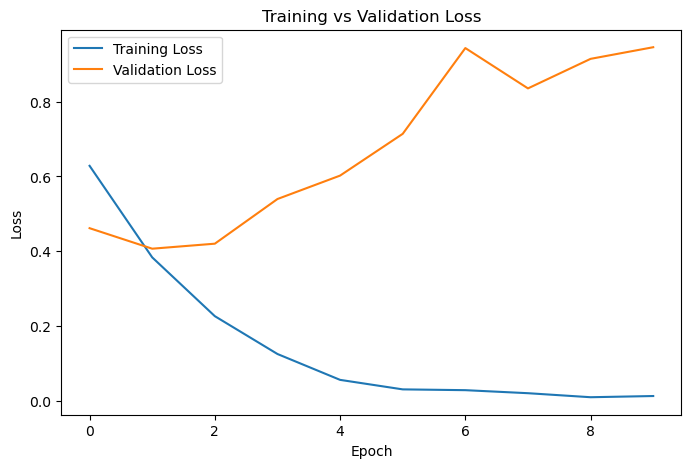

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8022 - loss: 0.9281
Final Test Loss: 0.928058385848999
Final Test Accuracy: 80.22000193595886 %


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
data = pd.read_csv(r"C:\Users\23adsb48\Downloads\archive (1)\IMDB Dataset.csv")
print("Dataset Shape:", data.shape)
print(data.head())
data['sentiment'] = data['sentiment'].map({'positive':1, 'negative':0})
X = data['review']
y = data['sentiment']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
vocab_size = 10000
tokenizer = Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)
max_length = 200

X_train_pad = pad_sequences(X_train_seq, maxlen=max_length)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length)
model = Sequential()

model.add(Embedding(input_dim=vocab_size, output_dim=32, input_length=max_length))
model.add(SimpleRNN(32))
model.add(Dense(1, activation='sigmoid'))
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()
history = model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
test_loss, test_accuracy = model.evaluate(X_test_pad, y_test)
print("Final Test Loss:", test_loss)
print("Final Test Accuracy:", test_accuracy*100, "%")

Dataset Shape: (50000, 2)
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


C:\Users\23adsb48\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.6386 - loss: 0.6155 - val_accuracy: 0.7879 - val_loss: 0.4648
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.8318 - loss: 0.4097 - val_accuracy: 0.8317 - val_loss: 0.3907
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.8842 - loss: 0.2969 - val_accuracy: 0.8330 - val_loss: 0.3972
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - accuracy: 0.9236 - loss: 0.2098 - val_accuracy: 0.7634 - val_loss: 0.5432


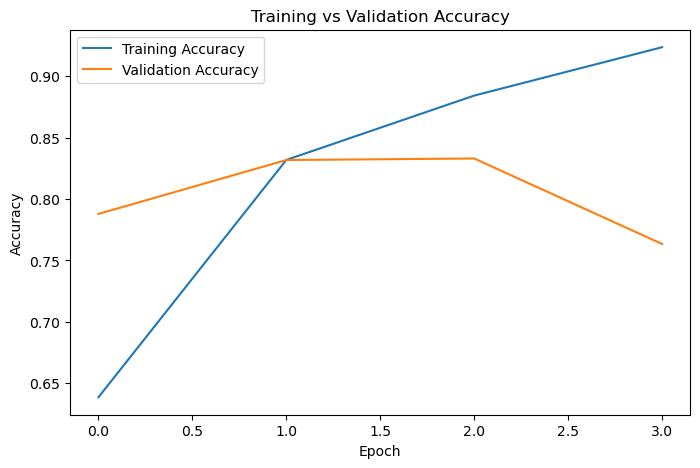

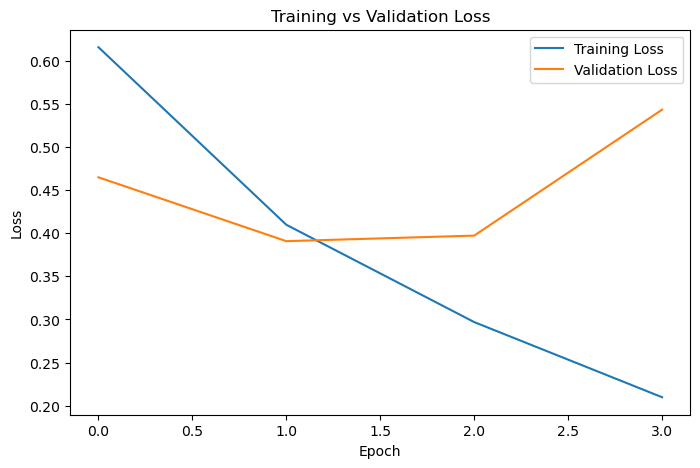

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8305 - loss: 0.3921
Final Test Loss: 0.39208078384399414
Final Test Accuracy: 83.05000066757202 %
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step

Confusion Matrix:
 [[4259  702]
 [ 993 4046]]


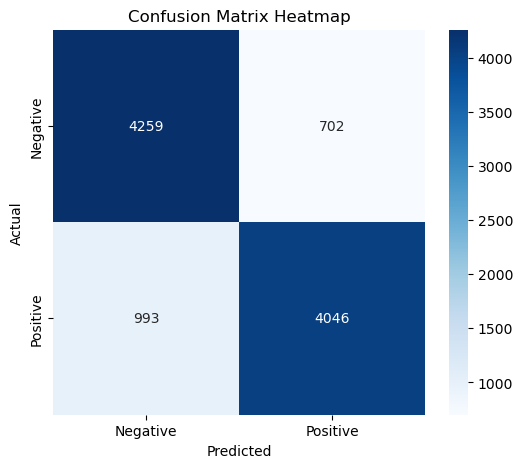


Classification Report:
               precision    recall  f1-score   support

    Negative       0.81      0.86      0.83      4961
    Positive       0.85      0.80      0.83      5039

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000



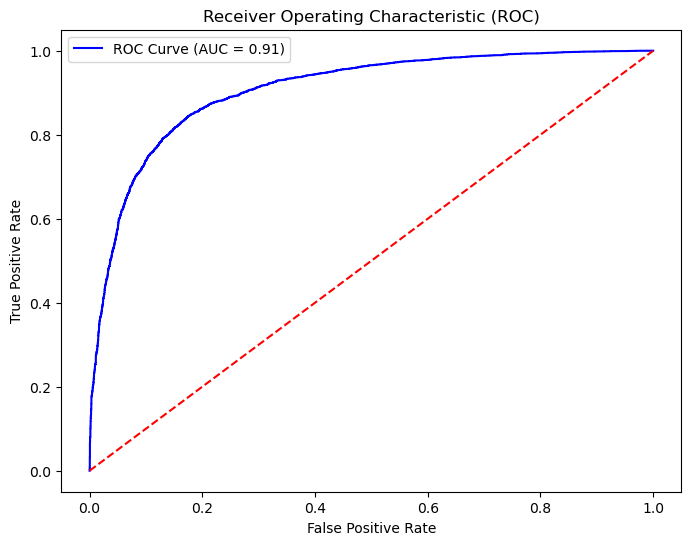

In [3]:
# RNN for Sentiment Classification using IMDB CSV Dataset

# 1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


# 2. Load Dataset
data = pd.read_csv(r"C:\Users\23adsb48\Downloads\archive (1)\IMDB Dataset.csv")

print("Dataset Shape:", data.shape)
print(data.head())


# 3. Convert Sentiment Labels
data['sentiment'] = data['sentiment'].map({'positive':1, 'negative':0})


# 4. Split Dataset
X = data['review']
y = data['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# 5. Tokenization
vocab_size = 10000

tokenizer = Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)


# 6. Padding
max_length = 200

X_train_pad = pad_sequences(X_train_seq, maxlen=max_length)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length)


# 7. Build RNN Model (with Dropout)
model = Sequential()

model.add(Embedding(input_dim=vocab_size, output_dim=32, input_length=max_length))
model.add(SimpleRNN(32))
model.add(Dropout(0.5))  # helps prevent overfitting
model.add(Dense(1, activation='sigmoid'))


# 8. Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


# 9. Model Summary
model.summary()


# 10. Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)


# 11. Train Model
history = model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)


# 12. Plot Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


# 13. Plot Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


# 14. Final Evaluation
test_loss, test_accuracy = model.evaluate(X_test_pad, y_test)

print("Final Test Loss:", test_loss)
print("Final Test Accuracy:", test_accuracy*100, "%")

# 15. Extended Evaluation Metrics
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns

# Predictions
y_pred_prob = model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype("int32")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Plot Confusion Matrix Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report (Precision, Recall, F1-score)
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=['Negative','Positive']))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='red', linestyle='--')
plt.title('Receiver Operating Characteristic (ROC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()


Dataset Shape: (50000, 2)
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


C:\Users\23adsb48\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.6650 - loss: 0.5899 - val_accuracy: 0.8300 - val_loss: 0.3979
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.8413 - loss: 0.3863 - val_accuracy: 0.8393 - val_loss: 0.3931
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.8750 - loss: 0.3191 - val_accuracy: 0.8360 - val_loss: 0.3840
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9128 - loss: 0.2386 - val_accuracy: 0.6607 - val_loss: 0.6945
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.9272 - loss: 0.2054 - val_accuracy: 0.8146 - val_loss: 0.4719
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 27ms/step - accuracy: 0.9332 - loss: 0.1949 - val_accuracy: 0.8328 - val_loss: 0.4888
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.9747 - loss: 0.0906 - val_accuracy: 0.7821 - val_loss: 0.6348
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.9835 - loss: 0.0648 - 

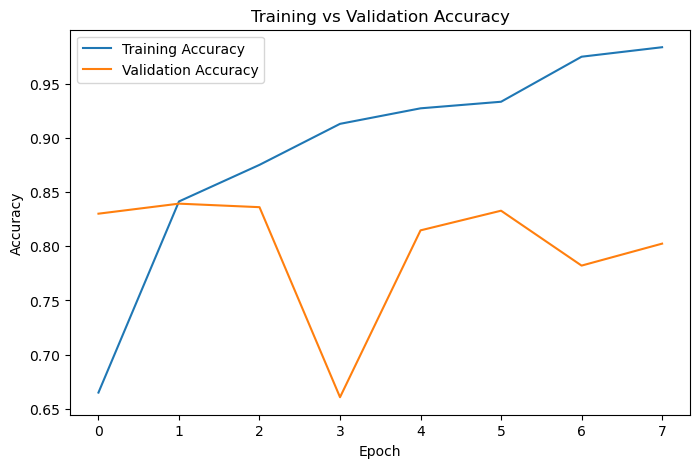

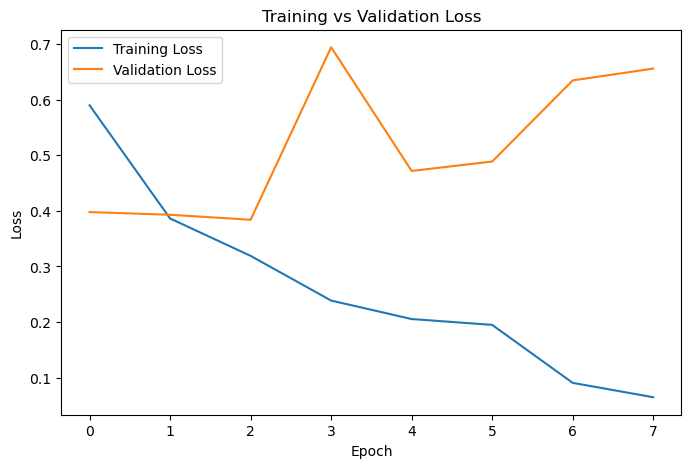

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8496 - loss: 0.3741
Final Test Loss: 0.37414538860321045
Final Test Accuracy: 84.96000170707703 %
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step

Confusion Matrix:
 [[4062  899]
 [ 605 4434]]


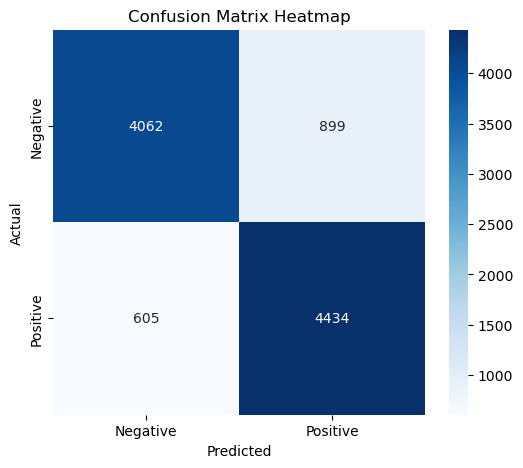


Classification Report:
               precision    recall  f1-score   support

    Negative       0.87      0.82      0.84      4961
    Positive       0.83      0.88      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



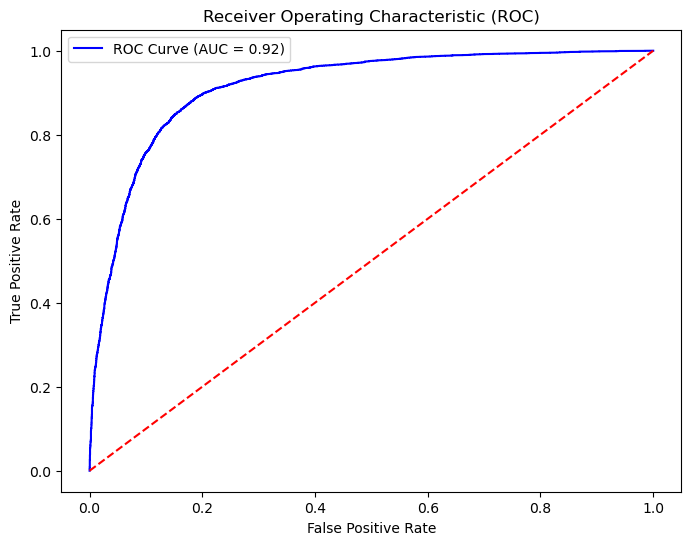

In [4]:
# RNN for Sentiment Classification using IMDB CSV Dataset

# 1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2


# 2. Load Dataset
data = pd.read_csv(r"C:\Users\23adsb48\Downloads\archive (1)\IMDB Dataset.csv")

print("Dataset Shape:", data.shape)
print(data.head())


# 3. Convert Sentiment Labels
data['sentiment'] = data['sentiment'].map({'positive':1, 'negative':0})


# 4. Split Dataset
X = data['review']
y = data['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# 5. Tokenization
vocab_size = 10000

tokenizer = Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)


# 6. Padding
max_length = 200

X_train_pad = pad_sequences(X_train_seq, maxlen=max_length)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length)


# 7. Build RNN Model (with Dropout + L2 Regularization)
model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=32, input_length=max_length))
model.add(SimpleRNN(32))
model.add(Dropout(0.5))  # helps prevent overfitting
model.add(Dense(1, activation='sigmoid', kernel_regularizer=l2(0.001)))  # L2 regularization


# 8. Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


# 9. Model Summary
model.summary()


# 10. Early Stopping (patience increased to 5)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


# 11. Train Model (up to 10 epochs)
history = model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)


# 12. Plot Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


# 13. Plot Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


# 14. Final Evaluation
test_loss, test_accuracy = model.evaluate(X_test_pad, y_test)
print("Final Test Loss:", test_loss)
print("Final Test Accuracy:", test_accuracy*100, "%")


# 15. Extended Evaluation Metrics
# Predictions
y_pred_prob = model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype("int32")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Plot Confusion Matrix Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report (Precision, Recall, F1-score)
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=['Negative','Positive']))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='red', linestyle='--')
plt.title('Receiver Operating Characteristic (ROC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()
